In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import load_raw_transactions, clean_transactions

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

In [2]:
df = load_raw_transactions("../data/raw/OnlineRetail.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (410425, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,543213,48187,DOORMAT NEW ENGLAND,110,2011-07-22 18:31:00,7.98,12873,Switzerland
1,566013,21080,SET/20 RED RETROSPOT PAPER NAPKINS,123,2011-06-16 07:24:00,1.32,14647,Netherlands
2,554663,21755,LOVE BUILDING BLOCK WORD,18,2011-01-28 19:38:00,6.30,13744,United Kingdom
3,546219,21212,PACK OF 72 RETROSPOT CAKE CASES,33,2011-08-13 16:51:00,1.16,NaN,United Kingdom
4,591112,21754,HOME BUILDING BLOCK WORD,112,2011-11-18 07:42:00,5.96,16651,United Kingdom


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 410425 entries, 0 to 410424
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    410425 non-null  str           
 1   StockCode    410425 non-null  str           
 2   Description  409197 non-null  str           
 3   Quantity     410425 non-null  int64         
 4   InvoiceDate  410425 non-null  datetime64[us]
 5   UnitPrice    410425 non-null  float64       
 6   CustomerID   320308 non-null  str           
 7   Country      410425 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(5)
memory usage: 46.0 MB


In [4]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
InvoiceNo,0,0.0
StockCode,0,0.0
Description,1228,0.3
Quantity,0,0.0
InvoiceDate,0,0.0
UnitPrice,0,0.0
CustomerID,90117,22.0
Country,0,0.0


In [5]:
n_cancellations = df["InvoiceNo"].astype(str).str.startswith("C").sum()
print(f"Cancellation line items: {n_cancellations:,} ({n_cancellations/len(df):.1%} of rows)")

non_product = df[df["StockCode"].isin(["POST", "D", "M", "BANK CHARGES", "DOT", "CRUK"])]
print(f"Non-product rows (postage/discount/manual/etc): {len(non_product):,}")

zero_price = (df["UnitPrice"] <= 0).sum()
print(f"Rows with UnitPrice <= 0 (likely data errors): {zero_price:,}")

Cancellation line items: 7,953 (1.9% of rows)
Non-product rows (postage/discount/manual/etc): 800
Rows with UnitPrice <= 0 (likely data errors): 400


In [6]:
df_clean = clean_transactions(df)
print(f"Rows before cleaning: {len(df):,}")
print(f"Rows after cleaning:  {len(df_clean):,}")
print(f"Unique customers retained: {df_clean['CustomerID'].nunique():,}")

df_clean.to_csv("../data/processed/transactions_clean.csv", index=False)

Rows before cleaning: 410,425
Rows after cleaning:  318,241
Unique customers retained: 4,334


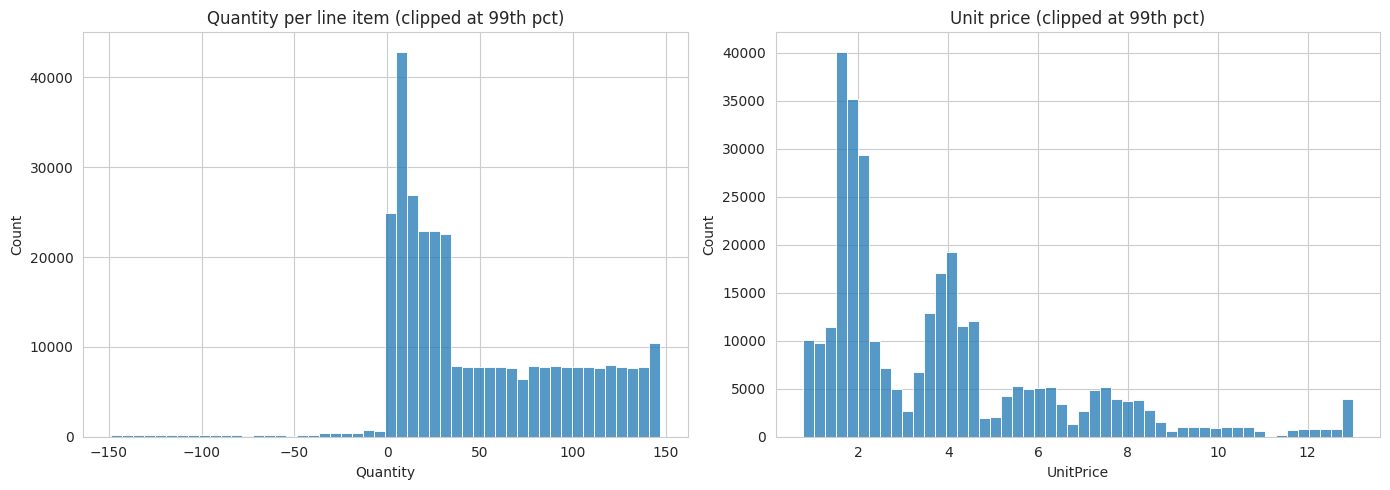

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_clean["Quantity"].clip(upper=df_clean["Quantity"].quantile(0.99)), bins=50, ax=axes[0])
axes[0].set_title("Quantity per line item (clipped at 99th pct)")

sns.histplot(df_clean["UnitPrice"].clip(upper=df_clean["UnitPrice"].quantile(0.99)), bins=50, ax=axes[1])
axes[1].set_title("Unit price (clipped at 99th pct)")
plt.tight_layout()
plt.savefig("../reports/figures/01_quantity_price_dist.png", dpi=120)
plt.show()

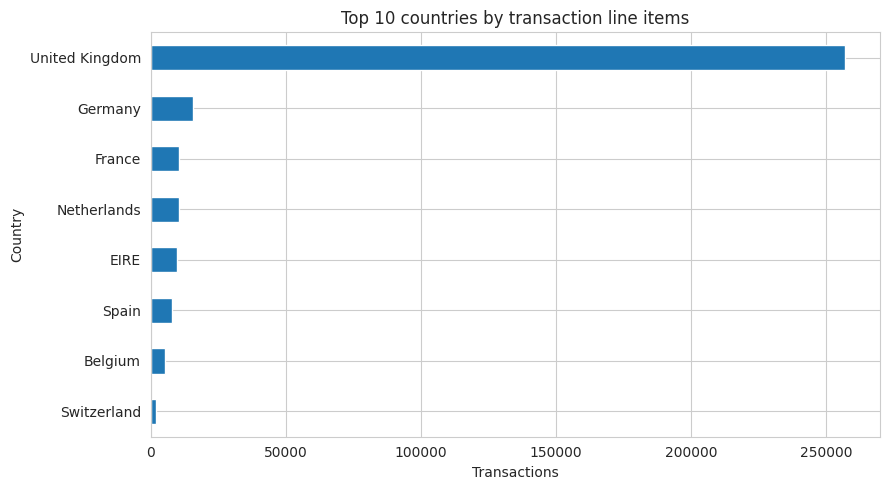

In [8]:
top_countries = df_clean["Country"].value_counts().head(10)
top_countries.plot(kind="barh")
plt.title("Top 10 countries by transaction line items")
plt.xlabel("Transactions")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("../reports/figures/01_top_countries.png", dpi=120)
plt.show()

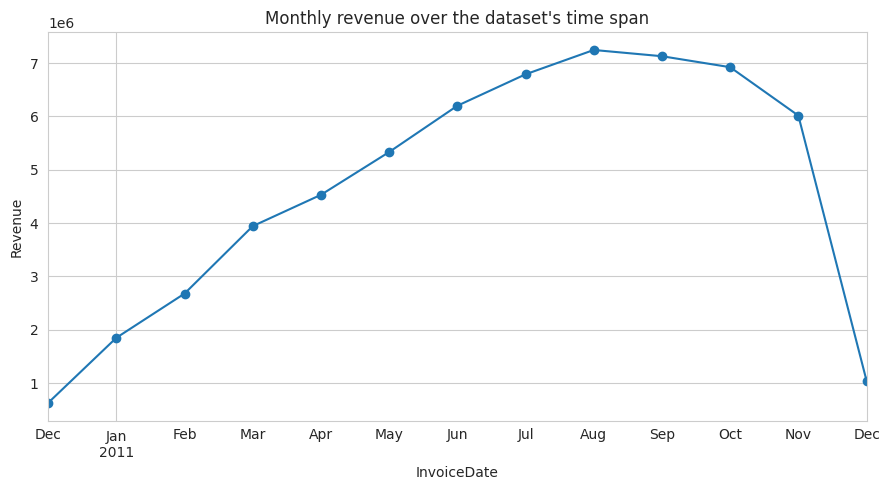

In [9]:
monthly_revenue = df_clean.set_index("InvoiceDate").resample("ME")["TotalPrice"].sum()
monthly_revenue.plot(marker="o")
plt.title("Monthly revenue over the dataset's time span")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("../reports/figures/01_monthly_revenue.png", dpi=120)
plt.show()